<a href="https://colab.research.google.com/github/Korchomnyi-Ivan/Korchomnyi-Ivan-Machine-3-15/blob/main/Korchomnyi%2012.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
meowmeowmeowmeowmeow_gtsrb_german_traffic_sign_path = kagglehub.dataset_download('meowmeowmeowmeowmeow/gtsrb-german-traffic-sign')

print('Data source import complete.')


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

from tensorflow.keras.layers import (Input, Rescaling, RandomFlip, RandomRotation, RandomContrast,
                                     Conv2D, BatchNormalization, MaxPool2D,
                                     GlobalAveragePooling2D, Dense, Dropout)

from tensorflow.keras.regularizers import l2

In [ ]:
train_csv_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv"
test_csv_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv"
base_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

train_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [ ]:
test_df.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


In [ ]:
X_train = []
y_train = []

for _, row in train_df.iterrows():
    img_path = os.path.join(base_path, row["Path"])
    img = image.load_img(img_path, target_size=(32, 32))
    img_array = image.img_to_array(img)

    X_train.append(img_array)
    y_train.append(row["ClassId"])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

X_train: (39209, 32, 32, 3)
y_train: (39209,)


In [ ]:
X_test = []
y_test = []

for _, row in test_df.iterrows():
    img_path = os.path.join(base_path, row["Path"])
    img = image.load_img(img_path, target_size=(32, 32))
    img_array = image.img_to_array(img)

    X_test.append(img_array)
    y_test.append(row["ClassId"])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (12630, 32, 32, 3)
y_test: (12630,)


In [ ]:
print ("Кількість класів:", len(np.unique(y_train)))

Кількість класів: 43


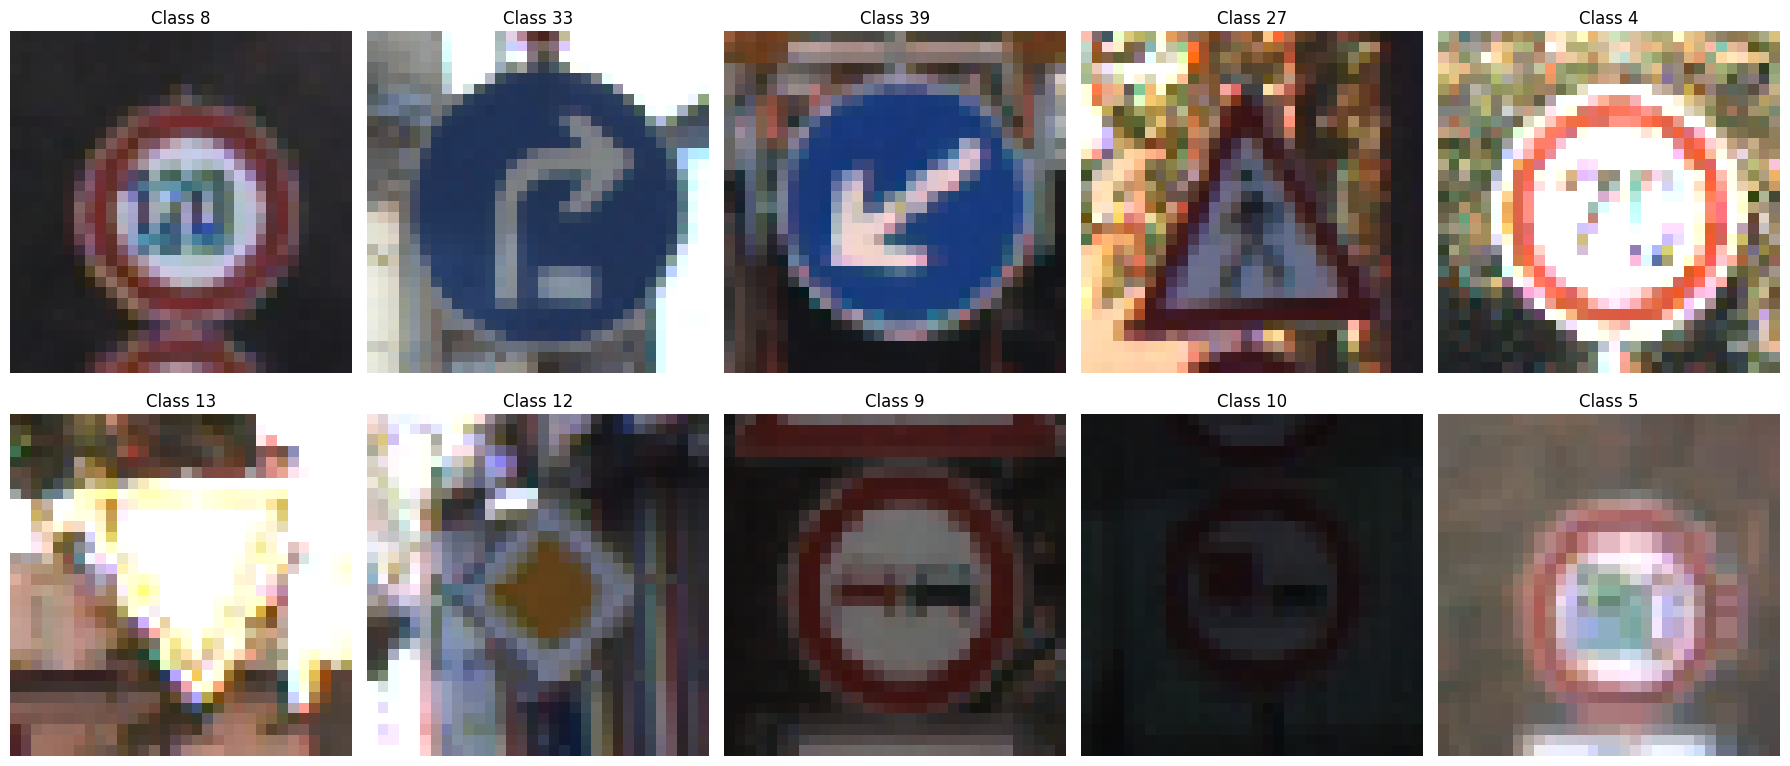

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

indices = random.sample(range(len(X_train)), 10)

plt.figure(figsize=(18, 8))

for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)

    img = X_train[idx]
    if img.max() <= 1.0:
        plt.imshow(img)
    else:
        plt.imshow(img.astype("uint8"))

    class_id = np.argmax(y_train[idx]) if len(y_train[idx].shape)>0 and y_train[idx].shape[0]>1 else int(y_train[idx])

    plt.title(f"Class {class_id}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
height, width, channels = 32, 32, 3
NUM_CATEGORIES = 43

model = Sequential([
    Input(shape=(height, width, channels)),

    Rescaling(1./255),
    RandomFlip("horizontal"),
    RandomRotation(0.05),
    RandomContrast(0.1),

    Conv2D(32, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(32, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPool2D(),

    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    Conv2D(64, (3,3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPool2D(),

    Conv2D(128, (3,3), padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPool2D(),

    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CATEGORIES, activation="softmax")
])

In [ ]:
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import TopKCategoricalAccuracy

LOSS = CategoricalCrossentropy()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=LOSS,
    metrics=[
        "accuracy",
        TopKCategoricalAccuracy(k=3, name="top3")
    ]
)

cb = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    shuffle=True,
    callbacks=cb,
    verbose=1
)

Epoch 1/50


I0000 00:00:1776797107.301518     208 cuda_dnn.cc:529] Loaded cuDNN version 91002


1226/1226 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.1738 - loss: 3.2423 - val_accuracy: 0.4726 - val_loss: 1.7755 - learning_rate: 3.0000e-04
Epoch 2/50
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4985 - loss: 1.6091 - val_accuracy: 0.7327 - val_loss: 0.8563 - learning_rate: 3.0000e-04
Epoch 3/50
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.7445 - loss: 0.8299 - val_accuracy: 0.8575 - val_loss: 0.4818 - learning_rate: 3.0000e-04
Epoch 4/50
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8501 - loss: 0.4817 - val_accuracy: 0.9086 - val_loss: 0.3096 - learning_rate: 3.0000e-04
Epoch 5/50
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.8958 - loss: 0.3347 - val_accuracy: 0.9154 - val_loss: 0.3065 - learning_rate: 3.0000e-04
Epoch 6/50
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9175 - loss: 0.2646 - val_accuracy: 0.9331 - val_loss: 0.2662 - learning_rate: 3.0000e-04
Epoch 7/50
1226/1226 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/

In [ ]:
model. summary ()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_2               │ (None, 32, 32, 3)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             

 Total params: 487,011 (1.86 MB)

 Trainable params: 162,123 (633.29 KB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 324,248 (1.24 MB)

In [ ]:
training_accuracy = history.history["accuracy"]
training_loss = history.history["loss"]
validation_accuracy = history.history["val_accuracy"]
validation_loss = history.history["val_loss"]

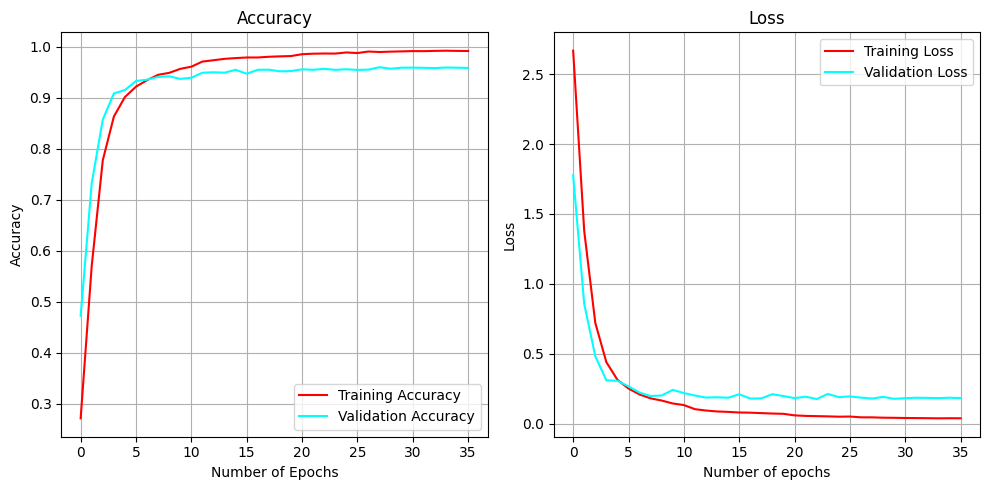

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.plot(training_accuracy, color = "red", label = "Training Accuracy")
plt.plot(validation_accuracy, color = "cyan", label = "Validation Accuracy")
plt.legend()
plt.grid(True)
plt.title("Accuracy")
plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(training_loss, color = "red", label = "Training Loss")
plt.plot(validation_loss, color = "cyan", label = "Validation Loss")
plt.grid(True)
plt.legend()
plt.title("Loss")
plt.xlabel("Number of epochs")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [25.0..92.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [25.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [20.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [92.0..247.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.0..200.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [5.0..71.0].
Clipping input data to the valid range for imshow with RGB d

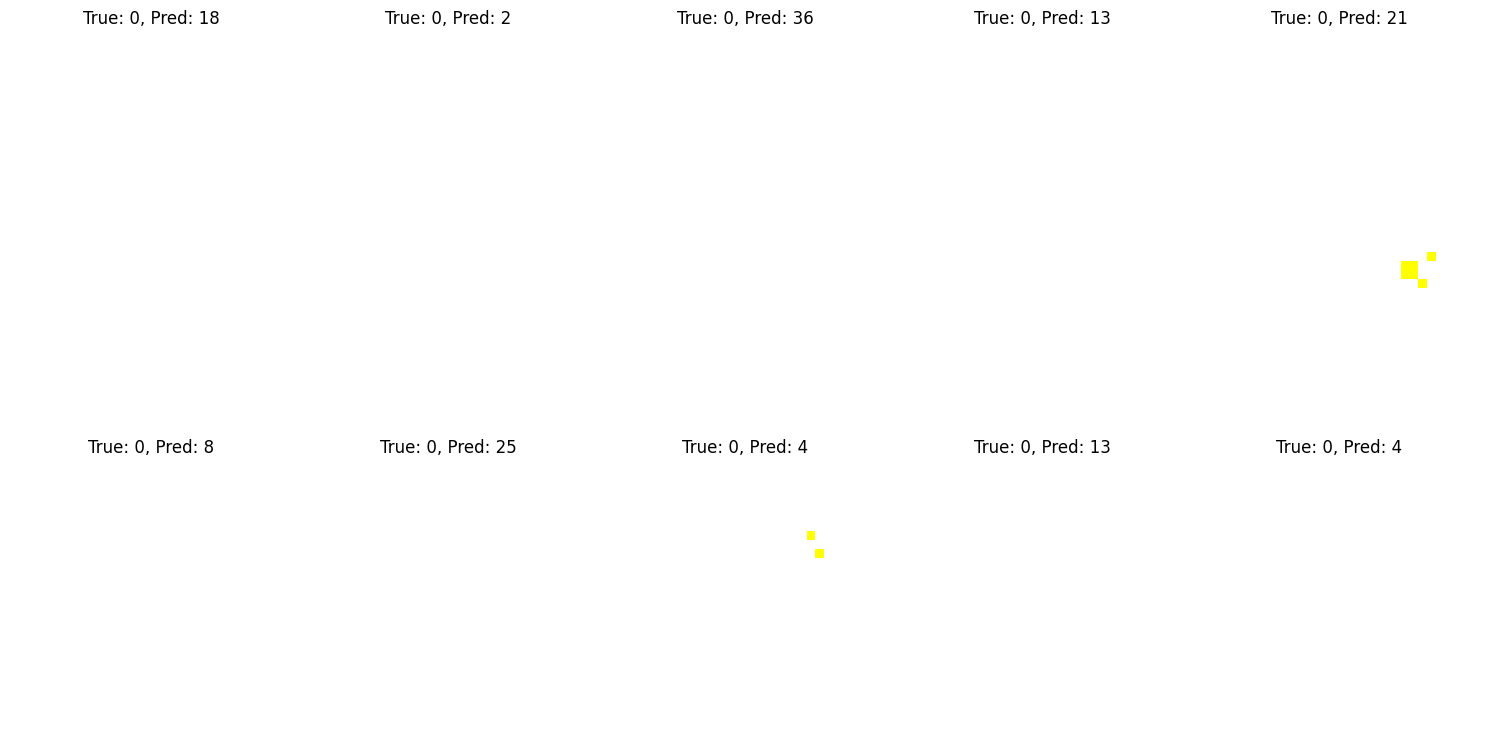

In [ ]:
random_indices = np.random.choice(len(X_test), size=10, replace=False)

y_pred = model.predict(X_test)

plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    plt.axis('off')

    true_class = np.argmax(y_test[idx])
    predicted_class = np.argmax(y_pred[idx])

    plt.title(f"True: {true_class}, Pred: {predicted_class}")

plt.tight_layout()
plt.show()

Висновок: Виконуючи роботу з датасетом , було завантажено та підготовлено зображення дорожніх знаків, а також сформовано навчальні та тестові вибірки для подальшого навчання моделі.